# Regional Job Advertisement Trends

Explore quarterly regional indices using the cleaned MBIE Jobs Online dataset.

Index values measure change relative to each region's baseline, not the number of vacancies.

In [1]:
from pathlib import Path

import pandas as pd

data_file = Path("../data/processed/regional_quarterly.csv")

regional = pd.read_csv(data_file, parse_dates=["Date"])

regional.head()

,Date,Auckland,Bay of Plenty,Canterbury,Gisborne Hawke's Bay,Marlborough/NelsonTasman/West Coast,Manawatu/Wanganui-Taranaki,Northland,Otago Southland,Waikato,Wellington
0,2010-12-01,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,2011-03-01,117.4,122.6,109.5,106.3,106.5,105.2,108.5,109.4,114.6,122.7
2,2011-06-01,123.8,115.0,139.8,101.8,100.0,106.0,109.6,108.3,119.4,122.2
3,2011-09-01,128.2,124.7,158.5,105.2,113.2,113.4,121.2,123.9,128.1,124.6
4,2011-12-01,101.0,106.0,140.5,104.3,114.8,101.7,109.1,120.0,105.8,103.1


In [2]:
regional.info()

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Date                                 63 non-null     datetime64[us]
 1   Auckland                             63 non-null     float64       
 2   Bay of Plenty                        63 non-null     float64       
 3   Canterbury                           63 non-null     float64       
 4   Gisborne Hawke's Bay                 63 non-null     float64       
 5   Marlborough/NelsonTasman/West Coast  63 non-null     float64       
 6   Manawatu/Wanganui-Taranaki           63 non-null     float64       
 7   Northland                            63 non-null     float64       
 8   Otago Southland                      63 non-null     float64       
 9   Waikato                              63 non-null     float64       
 10  Wellington                 

In [3]:
auckland = regional[["Date", "Auckland"]].copy()

In [4]:
auckland.head()

,Date,Auckland
0,2010-12-01,100.0
1,2011-03-01,117.4
2,2011-06-01,123.8
3,2011-09-01,128.2
4,2011-12-01,101.0


In [5]:
auckland["yoy_change_pct"] = (
    auckland["Auckland"].pct_change(periods=4, fill_method=None) * 100
)

auckland.tail(8)

,Date,Auckland,yoy_change_pct
55,2024-09-01,117.5,-31.923523
56,2024-12-01,93.7,-29.917726
57,2025-03-01,110.6,-25.270270
58,2025-06-01,104.8,-14.098361
59,2025-09-01,113.3,-3.574468
60,2025-12-01,93.2,-0.533618
61,2026-03-01,115.7,4.611212
62,2026-06-01,106.8,1.908397


In [6]:
regional_indices = regional.set_index("Date")

regional_yoy = regional_indices.pct_change(
    periods=4,
    fill_method=None
) * 100

In [7]:
regional_yoy.tail()

,Auckland,Bay of Plenty,Canterbury,Gisborne Hawke's Bay,Marlborough/NelsonTasman/West Coast,Manawatu/Wanganui-Taranaki,Northland,Otago Southland,Waikato,Wellington
Date,,,,,,,,,,
2025-06-01,-14.098361,-7.110439,-3.533569,-25.621415,-2.866699,-8.252853,2.108309,1.139694,-5.829384,-4.631380
2025-09-01,-3.574468,3.870254,11.788155,-3.166421,6.128748,-2.676182,-6.735553,15.781299,3.847981,8.891013
2025-12-01,-0.533618,6.963668,11.022044,-0.570033,9.452736,6.930693,0.168634,13.847709,9.564719,8.967083
2026-03-01,4.611212,15.664018,19.033928,12.555066,12.984587,18.277512,14.405712,15.978774,13.297872,12.393567
2026-06-01,1.908397,5.944625,17.887668,-0.514139,6.099361,12.488038,4.048583,11.590470,9.461500,9.811695


In [8]:
latest_growth = regional_yoy.iloc[-1].sort_values(ascending=False)

In [9]:
print("Quarter:", regional_yoy.index[-1].to_period("Q"))
latest_growth.round(2)

Quarter: 2026Q2


Canterbury                             17.89
Manawatu/Wanganui-Taranaki             12.49
Otago Southland                        11.59
Wellington                              9.81
Waikato                                 9.46
Marlborough/NelsonTasman/West Coast     6.10
Bay of Plenty                           5.94
Northland                               4.05
Auckland                                1.91
Gisborne Hawke's Bay                   -0.51
Name: 2026-06-01 00:00:00, dtype: float64

In [10]:
latest_summary = pd.DataFrame({
    "index_value": regional_indices.iloc[-1],
    "yoy_change_pct": regional_yoy.iloc[-1]
})

latest_summary = latest_summary.sort_values(
    "yoy_change_pct",
    ascending=False
)

latest_summary.round(2)

,index_value,yoy_change_pct
Canterbury,193.1,17.89
Manawatu/Wanganui-Taranaki,235.1,12.49
Otago Southland,346.6,11.59
Wellington,110.8,9.81
Waikato,217.5,9.46
Marlborough/NelsonTasman/West Coast,215.7,6.10
Bay of Plenty,260.2,5.94
Northland,257.0,4.05
Auckland,106.8,1.91
Gisborne Hawke's Bay,116.1,-0.51


In [11]:
growing_below_baseline = latest_summary.loc[
    (latest_summary["yoy_change_pct"] > 0)
    & (latest_summary["index_value"] < 100)
]

growing_below_baseline

,index_value,yoy_change_pct


In [12]:
growth = latest_summary["yoy_change_pct"]

print("Growing regional groupings:", (growth > 0).sum())
print("Declining regional groupings:", (growth < 0).sum())
print("Unchanged regional groupings:", (growth == 0).sum())

Growing regional groupings: 9
Declining regional groupings: 1
Unchanged regional groupings: 0


## Key Insights

- Canterbury recorded the fastest annual growth: its online job-advertisement index increased by 17.89% in 2026Q2 compared with 2025Q2.
- Growth was widespread: nine of the ten regional groupings recorded annual increases. Gisborne Hawke’s Bay was the only exception, declining by 0.51%.
- Index values do not measure vacancy counts: each regional index measures change relative to its own December 2010 baseline. A higher index therefore does not necessarily mean more advertised vacancies than another region.

## Regional annual growth comparison

Compare year-over-year changes in regional job-advertisement indices for the latest available quarter.

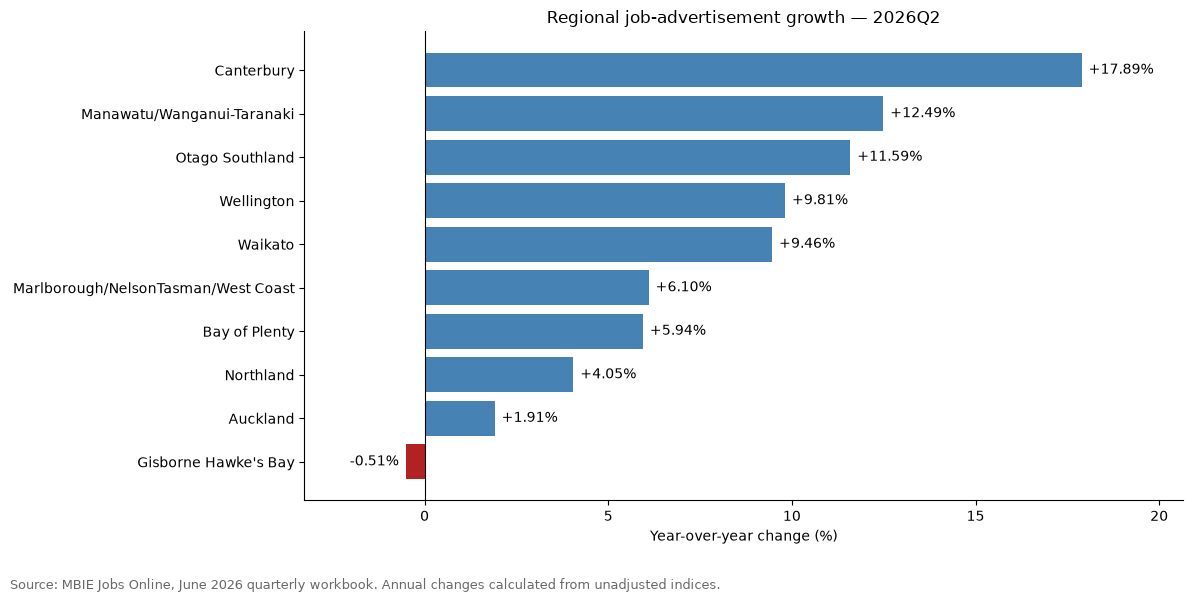

In [13]:
import matplotlib.pyplot as plt

growth_to_plot = latest_summary["yoy_change_pct"].sort_values()

colors = [
    "steelblue" if value >= 0 else "firebrick"
    for value in growth_to_plot
]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    growth_to_plot.index,
    growth_to_plot.values,
    color=colors
)

ax.bar_label(
    bars,
    labels=[f"{value:+.2f}%" for value in growth_to_plot],
    padding=5
)

ax.margins(x=0.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    "Source: MBIE Jobs Online, June 2026 quarterly workbook. "
    "Annual changes calculated from unadjusted indices.",
    fontsize=9,
    color="dimgray"
)

latest_quarter = regional_indices.index[-1].to_period("Q")

ax.set_title(f"Regional job-advertisement growth — {latest_quarter}")
ax.set_xlabel("Year-over-year change (%)")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)

fig.tight_layout(rect=[0, 0.06, 1, 1])

figure_path = Path("../reports/figures/regional_yoy_growth_2026Q2.png")

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Annual growth trends across selected regions

Compare year-over-year changes in Auckland, Wellington and Canterbury from 2019 onward.

In [14]:
selected_regions = ["Auckland", "Wellington", "Canterbury"]

selected_growth = regional_yoy.loc[
    "2019-01-01":,
    selected_regions
].copy()

selected_growth.head()

,Auckland,Wellington,Canterbury
Date,,,
2019-03-01,2.695035,12.341772,-2.029361
2019-06-01,-4.983849,5.892857,-11.406518
2019-09-01,-4.421149,6.321185,-6.461275
2019-12-01,-6.497022,2.316076,-9.195980
2020-03-01,-15.377532,-7.267606,-19.832525


In [15]:
print("Shape:", selected_growth.shape)
print("First quarter:", selected_growth.index.min().to_period("Q"))
print("Last quarter:", selected_growth.index.max().to_period("Q"))

selected_growth.isna().sum()

Shape: (30, 3)
First quarter: 2019Q1
Last quarter: 2026Q2


Auckland      0
Wellington    0
Canterbury    0
dtype: int64

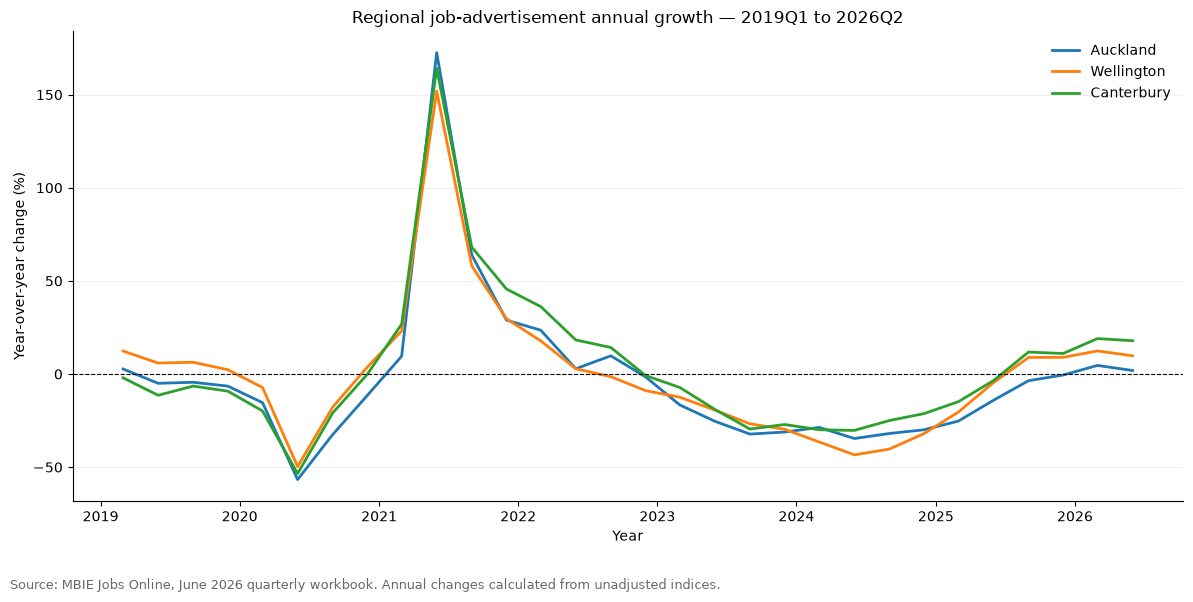

In [16]:
fig_trend, ax_trend = plt.subplots(figsize=(12, 6))

for region in selected_regions:
    ax_trend.plot(
        selected_growth.index,
        selected_growth[region],
        label=region,
        linewidth=2
    )

ax_trend.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax_trend.set_title(
    "Regional job-advertisement annual growth — 2019Q1 to 2026Q2"
)
ax_trend.set_xlabel("Year")
ax_trend.set_ylabel("Year-over-year change (%)")

ax_trend.legend(frameon=False)
ax_trend.grid(axis="y", alpha=0.2)
ax_trend.spines["top"].set_visible(False)
ax_trend.spines["right"].set_visible(False)

fig_trend.text(
    0.01,
    0.01,
    "Source: MBIE Jobs Online, June 2026 quarterly workbook. "
    "Annual changes calculated from unadjusted indices.",
    fontsize=9,
    color="dimgray"
)

fig_trend.tight_layout(rect=[0, 0.06, 1, 1])

trend_path = Path(
    "../reports/figures/regional_yoy_trends_2019Q1_2026Q2.png"
)

fig_trend.savefig(
    trend_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [17]:
peak_growth = pd.DataFrame({
    "peak_yoy_pct": selected_growth.max(),
    "peak_quarter": selected_growth.idxmax().dt.to_period("Q")
})

peak_growth.round({"peak_yoy_pct": 2})

,peak_yoy_pct,peak_quarter
Auckland,172.53,2021Q2
Wellington,151.84,2021Q2
Canterbury,164.14,2021Q2


In [18]:
comparison_dates = pd.to_datetime([
    "2019-06-01",
    "2020-06-01",
    "2021-06-01"
])

base_comparison = regional_indices.loc[
    comparison_dates,
    selected_regions
].copy()

base_comparison.index = base_comparison.index.to_period("Q")

base_comparison

,Auckland,Wellington,Canterbury
2019Q2,205.9,177.9,206.6
2020Q2,89.2,89.5,96.2
2021Q2,243.1,225.4,254.1


In [19]:
two_year_change = (
    base_comparison.loc["2021Q2"]
    / base_comparison.loc["2019Q2"]
    - 1
) * 100

two_year_change.round(2)

Auckland      18.07
Wellington    26.70
Canterbury    22.99
dtype: float64

### Conclusion: Regional growth and comparison-base effects

All three regions recorded their highest year-over-year growth in 2021Q2. Auckland led at 172.53%, followed by Canterbury at 164.14% and Wellington at 151.84%.

However, growth from 2019Q2 to 2021Q2 was substantially smaller: 18.07% in Auckland, 22.99% in Canterbury, and 26.70% in Wellington. The large annual increases therefore partly reflect the low 2020Q2 comparison base.

Auckland had the strongest one-year rebound, while Wellington recorded the largest two-year increase. This demonstrates why growth rates should be interpreted alongside index levels and clearly specified comparison periods. These results alone do not establish the causes of the changes.

## Reshaping regional indices

Convert the wide regional dataset into long format, with one
observation per region and quarter.

In [20]:
regional_long = regional.melt(
    id_vars="Date",
    var_name="region",
    value_name="index_value"
)

regional_long.head()

,Date,region,index_value
0,2010-12-01,Auckland,100.0
1,2011-03-01,Auckland,117.4
2,2011-06-01,Auckland,123.8
3,2011-09-01,Auckland,128.2
4,2011-12-01,Auckland,101.0


In [21]:
print("Wide shape:", regional.shape)
print("Long shape:", regional_long.shape)
print("Regional groupings:", regional_long["region"].nunique())

Wide shape: (63, 11)
Long shape: (630, 3)
Regional groupings: 10


In [22]:
observations_per_region = (
    regional_long.groupby("region").size()
)

observations_per_region

region
Auckland                               63
Bay of Plenty                          63
Canterbury                             63
Gisborne Hawke's Bay                   63
Manawatu/Wanganui-Taranaki             63
Marlborough/NelsonTasman/West Coast    63
Northland                              63
Otago Southland                        63
Waikato                                63
Wellington                             63
dtype: int64

In [23]:
print(
    "Duplicate region-date pairs:",
    regional_long.duplicated(subset=["Date", "region"]).sum()
)

regional_long.isna().sum()

Duplicate region-date pairs: 0


Date           0
region         0
index_value    0
dtype: int64

### Summarize each region with groupby()

In [24]:
regional_summary = (
    regional_long
    .groupby("region")
    .agg(
        observations=("index_value", "size"),
        lowest_index=("index_value", "min"),
        highest_index=("index_value", "max")
    )
)

regional_summary.round(2)

,observations,lowest_index,highest_index
region,,,
Auckland,63,89.2,254.7
Bay of Plenty,63,100.0,564.0
Canterbury,63,96.2,332.1
Gisborne Hawke's Bay,63,100.0,507.7
Manawatu/Wanganui-Taranaki,63,100.0,432.3
Marlborough/NelsonTasman/West Coast,63,100.0,444.1
Northland,63,100.0,482.7
Otago Southland,63,100.0,559.4
Waikato,63,100.0,413.7


In [25]:
peak_row_indices = (
    regional_long.groupby("region")["index_value"].idxmax()
)

regional_peaks = regional_long.loc[
    peak_row_indices,
    ["region", "Date", "index_value"]
].copy()

regional_peaks["peak_quarter"] = (
    regional_peaks["Date"].dt.to_period("Q")
)

regional_peaks[["region", "peak_quarter", "index_value"]]

,region,peak_quarter,index_value
47,Auckland,2022Q3,254.7
108,Bay of Plenty,2022Q1,564.0
173,Canterbury,2022Q3,332.1
234,Gisborne Hawke's Bay,2022Q1,507.7
362,Manawatu/Wanganui-Taranaki,2022Q3,432.3
297,Marlborough/NelsonTasman/West Coast,2022Q1,444.1
423,Northland,2022Q1,482.7
488,Otago Southland,2022Q3,559.4
549,Waikato,2022Q1,413.7
610,Wellington,2021Q3,242.6


In [26]:
regional_reconstructed = regional_long.pivot(
    index="Date",
    columns="region",
    values="index_value"
)

regional_reconstructed = regional_reconstructed.reindex(
    index=regional_indices.index,
    columns=regional_indices.columns
)

regional_reconstructed.columns.name = regional_indices.columns.name

pd.testing.assert_frame_equal(
    regional_indices,
    regional_reconstructed,
    check_dtype=False,
    check_column_type=False
)

print("Reshape verification passed")

Reshape verification passed


In [27]:
regional_long.to_csv(
    Path("../data/processed/regional_quarterly_long.csv"),
    index=False
)

### Conclusion: Regional data structure and historical peaks

Reshaping produced 630 observations: 63 quarters for each of 10 regional groupings. Every region–quarter pair is unique, and no values are missing.

Peak index levels occurred at different times. Five regional groupings peaked in 2022Q1, four in 2022Q3, and Wellington in 2021Q3. These are the highest observed index levels, not the highest annual growth rates or vacancy counts. As the indices are unadjusted, seasonal patterns may influence peak timing.

### Measure change from historical peaks

In [28]:
peak_table = regional_peaks[
    ["region", "peak_quarter", "index_value"]
].rename(columns={"index_value": "peak_index"})

In [29]:
peak_table

,region,peak_quarter,peak_index
47,Auckland,2022Q3,254.7
108,Bay of Plenty,2022Q1,564.0
173,Canterbury,2022Q3,332.1
234,Gisborne Hawke's Bay,2022Q1,507.7
362,Manawatu/Wanganui-Taranaki,2022Q3,432.3
297,Marlborough/NelsonTasman/West Coast,2022Q1,444.1
423,Northland,2022Q1,482.7
488,Otago Southland,2022Q3,559.4
549,Waikato,2022Q1,413.7
610,Wellington,2021Q3,242.6


In [30]:
latest_date = regional_long["Date"].max()

latest_table = regional_long.loc[
    regional_long["Date"] == latest_date,
    ["region", "index_value"]
].rename(columns={"index_value": "latest_index"})

In [31]:
latest_table

,region,latest_index
62,Auckland,106.8
125,Bay of Plenty,260.2
188,Canterbury,193.1
251,Gisborne Hawke's Bay,116.1
314,Marlborough/NelsonTasman/West Coast,215.7
377,Manawatu/Wanganui-Taranaki,235.1
440,Northland,257.0
503,Otago Southland,346.6
566,Waikato,217.5
629,Wellington,110.8


### Combine peak and latest values

In [32]:
peak_comparison = peak_table.merge(
    latest_table,
    on="region",
    how="inner",
    validate="one_to_one"
)

peak_comparison

,region,peak_quarter,peak_index,latest_index
0,Auckland,2022Q3,254.7,106.8
1,Bay of Plenty,2022Q1,564.0,260.2
2,Canterbury,2022Q3,332.1,193.1
3,Gisborne Hawke's Bay,2022Q1,507.7,116.1
4,Manawatu/Wanganui-Taranaki,2022Q3,432.3,235.1
5,Marlborough/NelsonTasman/West Coast,2022Q1,444.1,215.7
6,Northland,2022Q1,482.7,257.0
7,Otago Southland,2022Q3,559.4,346.6
8,Waikato,2022Q1,413.7,217.5
9,Wellington,2021Q3,242.6,110.8


### Calculate percentage change from the peak

In [33]:
peak_comparison["change_from_peak_pct"] = (
    peak_comparison["latest_index"]
    / peak_comparison["peak_index"]
    - 1
) * 100

peak_comparison = peak_comparison.sort_values(
    "change_from_peak_pct"
)

peak_comparison.round({
    "peak_index": 1,
    "latest_index": 1,
    "change_from_peak_pct": 2
})

,region,peak_quarter,peak_index,latest_index,change_from_peak_pct
3,Gisborne Hawke's Bay,2022Q1,507.7,116.1,-77.13
0,Auckland,2022Q3,254.7,106.8,-58.07
9,Wellington,2021Q3,242.6,110.8,-54.33
1,Bay of Plenty,2022Q1,564.0,260.2,-53.87
5,Marlborough/NelsonTasman/West Coast,2022Q1,444.1,215.7,-51.43
8,Waikato,2022Q1,413.7,217.5,-47.43
6,Northland,2022Q1,482.7,257.0,-46.76
4,Manawatu/Wanganui-Taranaki,2022Q3,432.3,235.1,-45.62
2,Canterbury,2022Q3,332.1,193.1,-41.85
7,Otago Southland,2022Q3,559.4,346.6,-38.04


In [34]:
annual_growth = (
    regional_yoy.loc[latest_date]
    .rename("yoy_change_pct")
    .rename_axis("region")
    .reset_index()
)

peak_comparison = peak_comparison.merge(
    annual_growth,
    on="region",
    validate="one_to_one"
)

peak_comparison[
    ["region", "yoy_change_pct", "change_from_peak_pct"]
].round(2)

,region,yoy_change_pct,change_from_peak_pct
0,Gisborne Hawke's Bay,-0.51,-77.13
1,Auckland,1.91,-58.07
2,Wellington,9.81,-54.33
3,Bay of Plenty,5.94,-53.87
4,Marlborough/NelsonTasman/West Coast,6.10,-51.43
5,Waikato,9.46,-47.43
6,Northland,4.05,-46.76
7,Manawatu/Wanganui-Taranaki,12.49,-45.62
8,Canterbury,17.89,-41.85
9,Otago Southland,11.59,-38.04


In [35]:
peak_comparison.dtypes

region                            str
peak_quarter            period[Q-DEC]
peak_index                    float64
latest_index                  float64
change_from_peak_pct          float64
yoy_change_pct                float64
dtype: object

In [36]:
peak_comparison.loc[
    (peak_comparison["yoy_change_pct"] > 0) 
    & (peak_comparison["change_from_peak_pct"] < -50)
    ]

,region,peak_quarter,peak_index,latest_index,change_from_peak_pct,yoy_change_pct
1,Auckland,2022Q3,254.7,106.8,-58.068316,1.908397
2,Wellington,2021Q3,242.6,110.8,-54.328112,9.811695
3,Bay of Plenty,2022Q1,564.0,260.2,-53.865248,5.944625
4,Marlborough/NelsonTasman/West Coast,2022Q1,444.1,215.7,-51.429858,6.099361


### Conclusion: Recent growth versus historical peaks

In 2026Q2, all ten regional job-advertisement indices remained below
their observed historical peaks. Gisborne Hawke's Bay had the largest
percentage gap (77.13% below peak), while Otago Southland had the
smallest (38.04% below peak).

Auckland, Wellington, Bay of Plenty, and
Marlborough/NelsonTasman/West Coast recorded positive annual growth
but remained more than 50% below their respective peaks.

This shows that recent growth and change from historical peaks
describe different aspects of the data. Peaks occurred in different
quarters, and the indices are unadjusted, so these comparisons are
descriptive rather than seasonally adjusted recovery measures.